In [32]:
import numpy as np
import pandas as pd
import matplotlib as plt

In [33]:
def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    if mask.sum() == 0:
        return np.nan
    return np.sqrt(np.mean((y_true[mask] - y_pred[mask]) ** 2))

def mse(y_true, y_pred): 
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    if mask.sum() == 0:
        return np.nan
    return np.mean((y_true[mask] - y_pred[mask]) ** 2)

def mape(y_true, y_pred): 
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask])))


def qlike(test_actuals, test_preds): 
    test_actuals = np.asarray(test_actuals, dtype=float)
    test_preds = np.asarray(test_preds, dtype=float)

    test_qlike = np.mean(test_actuals / (test_preds + 1e-10) - np.log(test_actuals / (test_preds + 1e-10)) - 1)

    return test_qlike 

In [34]:
# test results from garch
test_garch = pd.read_csv('benchmark garch/garch.csv')
test_garch['var_garch_bench'] = np.exp(test_garch['var_garch_bench'])
test_garch['actual_var'] = np.exp(test_garch['actual_var'])

garch_rmse = rmse(test_garch['actual_var'], test_garch['var_garch_bench'])
garch_mse = mse(test_garch['actual_var'], test_garch['var_garch_bench'])
garch_mape = mape(test_garch['actual_var'], test_garch['var_garch_bench'])
garch_qlike = qlike(test_garch['actual_var'], test_garch['var_garch_bench'])

garch_rmse, garch_mse, garch_mape, garch_qlike

(0.0006515314758416832,
 4.244932640124419e-07,
 0.00040337506799161763,
 0.43333737612205614)

In [35]:
# test results from svr
test_svr = pd.read_csv('SVR/results/svr_test_results.csv')

svr_rmse = rmse(test_svr['actual_var'], test_svr['pred_var'])
svr_mse = mse(test_svr['actual_var'], test_svr['pred_var'])
svr_mape = mape(test_svr['actual_var'], test_svr['pred_var'])
svr_qlike = qlike(test_svr['actual_var'], test_svr['pred_var'])

svr_rmse, svr_mse, svr_mape, svr_qlike

(0.0006559127349776613,
 4.302215159058758e-07,
 0.00039421141675018373,
 0.45253174412718045)

In [36]:
test_svr

,date,forecast_origin_date,actual_target,pred_target,actual_var,pred_var,error
0,2024-10-20,2024-10-19,-9.314845,-8.260595,0.000090,0.000259,-1.054250
1,2024-10-21,2024-10-20,-7.873473,-7.789070,0.000381,0.000414,-0.084404
2,2024-10-22,2024-10-21,-8.046507,-7.589355,0.000320,0.000506,-0.457152
3,2024-10-23,2024-10-22,-8.161787,-7.572213,0.000285,0.000515,-0.589575
4,2024-10-24,2024-10-23,-7.997675,-7.567514,0.000336,0.000517,-0.430161
...,...,...,...,...,...,...,...
464,2026-01-27,2026-01-26,-7.631798,-8.054034,0.000485,0.000318,0.422237
465,2026-01-28,2026-01-27,-8.051862,-8.621227,0.000319,0.000180,0.569365
466,2026-01-29,2026-01-28,-6.734192,-7.986624,0.001190,0.000340,1.252432
467,2026-01-30,2026-01-29,-7.064056,-7.255229,0.000855,0.000706,0.191173


In [37]:
# test result from lstm-svr
test_lstmsvr = pd.read_csv('lstm-regimeaware/results/lstm-svr1.csv')
test_lstmsvr['var_svr'] = np.exp(test_lstmsvr['log_var_svr'])
test_lstmsvr['actual_var'] = np.exp(test_lstmsvr['actual_log_var'])

lstmsvr_rmse = rmse(test_lstmsvr['actual_var'], test_lstmsvr['var_svr'])
lstmsvr_mse = mse(test_lstmsvr['actual_var'], test_lstmsvr['var_svr'])
lstmsvr_mape = mape(test_lstmsvr['actual_var'], test_lstmsvr['var_svr'])
lstmsvr_qlike = qlike(test_lstmsvr['actual_var'], test_lstmsvr['var_svr'])

lstmsvr_rmse, lstmsvr_mse, lstmsvr_mape, lstmsvr_qlike


(0.0006656181380799012,
 4.430475057409545e-07,
 0.0003850403904514631,
 0.46256532976188147)

In [38]:
# test result from lstm-svr new
test_lstmsvr = pd.read_csv('lstm-regimeaware/results/lstm-svr3.csv')
test_lstmsvr['var_svr'] = np.exp(test_lstmsvr['log_var_svr'])
test_lstmsvr['actual_var'] = np.exp(test_lstmsvr['actual_log_var'])

lstmsvr_rmse = rmse(test_lstmsvr['actual_var'], test_lstmsvr['var_svr'])
lstmsvr_mse = mse(test_lstmsvr['actual_var'], test_lstmsvr['var_svr'])
lstmsvr_mape = mape(test_lstmsvr['actual_var'], test_lstmsvr['var_svr'])
lstmsvr_qlike = qlike(test_lstmsvr['actual_var'], test_lstmsvr['var_svr'])

lstmsvr_rmse, lstmsvr_mse, lstmsvr_mape, lstmsvr_qlike


(0.0006277285645398611,
 3.940431507392745e-07,
 0.0003722255310860858,
 0.40426678422092543)

In [39]:
# test result from lstm-svr (augmented)
test_lstmsvr_aug = pd.read_csv('lstm-regimeaware/results/lstm-svr2.csv')
test_lstmsvr_aug['var_svr'] = np.exp(test_lstmsvr_aug['log_var_svr'])
test_lstmsvr_aug['actual_var'] = np.exp(test_lstmsvr_aug['actual_log_var']) 

lstmsvr_aug_rmse = rmse(test_lstmsvr_aug['actual_var'], test_lstmsvr_aug['var_svr'])
lstmsvr_aug_mse = mse(test_lstmsvr_aug['actual_var'], test_lstmsvr_aug['var_svr'])
lstmsvr_aug_mape = mape(test_lstmsvr_aug['actual_var'], test_lstmsvr_aug['var_svr'])
lstmsvr_aug_qlike = qlike(test_lstmsvr_aug['actual_var'], test_lstmsvr_aug['var_svr'])

lstmsvr_aug_rmse, lstmsvr_aug_mse, lstmsvr_aug_mape, lstmsvr_aug_qlike

(0.0006650045149152619,
 4.4223100485768274e-07,
 0.0003899671366286451,
 0.4547191099927798)

In [40]:
# test results from rf-svr
test_rfsvr = pd.read_csv('rf-regimeaware/results/rf-svr_results.csv')
test_rfsvr['var_svr'] = np.exp(test_rfsvr['log_var_svr'])
test_rfsvr['actual_var'] = np.exp(test_rfsvr['actual_log_var'])

rfsvr_rmse = rmse(test_rfsvr['actual_var'], test_rfsvr['var_svr'])
rfsvr_mse = mse(test_rfsvr['actual_var'], test_rfsvr['var_svr'])
rfsvr_mape = mape(test_rfsvr['actual_var'], test_rfsvr['var_svr'])
rfsvr_qlike = qlike(test_rfsvr['actual_var'], test_rfsvr['var_svr'])

rfsvr_rmse, rfsvr_mse, rfsvr_mape, rfsvr_qlike

(0.0006745808637188235,
 4.550593416956339e-07,
 0.0003717123177621234,
 0.4819697593530643)

In [41]:
# test results from rf-svr new
test_rfsvr = pd.read_csv('rf-regimeaware/results/rf-svr3_results.csv')
test_rfsvr['var_svr'] = np.exp(test_rfsvr['log_var_svr'])
test_rfsvr['actual_var'] = np.exp(test_rfsvr['actual_log_var'])

rfsvr_rmse = rmse(test_rfsvr['actual_var'], test_rfsvr['var_svr'])
rfsvr_mse = mse(test_rfsvr['actual_var'], test_rfsvr['var_svr'])
rfsvr_mape = mape(test_rfsvr['actual_var'], test_rfsvr['var_svr'])
rfsvr_qlike = qlike(test_rfsvr['actual_var'], test_rfsvr['var_svr'])

rfsvr_rmse, rfsvr_mse, rfsvr_mape, rfsvr_qlike

(0.0006185566076714076,
 3.826122768939596e-07,
 0.00037744702998631757,
 0.4078125268061125)

In [42]:
# test results from rf-svr (augmented)
test_rfsvr_aug = pd.read_csv('rf-regimeaware/results/rf-svr2_results.csv')
test_rfsvr_aug['var_svr'] = np.exp(test_rfsvr_aug['log_var_svr'])
test_rfsvr_aug['actual_var'] = np.exp(test_rfsvr_aug['actual_log_var'])

rfsvr_aug_rmse = rmse(test_rfsvr_aug['actual_var'], test_rfsvr_aug['var_svr'])
rfsvr_aug_mse = mse(test_rfsvr_aug['actual_var'], test_rfsvr_aug['var_svr'])
rfsvr_aug_mape = mape(test_rfsvr_aug['actual_var'], test_rfsvr_aug['var_svr'])
rfsvr_aug_qlike = qlike(test_rfsvr_aug['actual_var'], test_rfsvr_aug['var_svr'])

rfsvr_aug_rmse, rfsvr_aug_mse, rfsvr_aug_mape, rfsvr_aug_qlike

(0.0006507143188977664,
 4.23429124818584e-07,
 0.0003841745210330134,
 0.4543225537117371)

In [43]:
test_lstmsvr_aug

,date,forecast_origin_date,actual_log_var,pred_regime,pred_prob_0,pred_prob_1,log_var_svr,error,var_svr,actual_var
0,2024-10-20,2024-10-19,-9.314845,0.0,0.997036,0.002964,-8.240928,-1.073917,0.000264,0.000090
1,2024-10-21,2024-10-20,-7.873473,0.0,0.669086,0.330914,-7.783885,-0.089588,0.000416,0.000381
2,2024-10-22,2024-10-21,-8.046507,1.0,0.000307,0.999694,-7.284555,-0.761953,0.000686,0.000320
3,2024-10-23,2024-10-22,-8.161787,1.0,0.000253,0.999747,-7.645655,-0.516132,0.000478,0.000285
4,2024-10-24,2024-10-23,-7.997675,1.0,0.000003,0.999997,-7.633365,-0.364309,0.000484,0.000336
...,...,...,...,...,...,...,...,...,...,...
464,2026-01-27,2026-01-26,-7.631798,1.0,0.148089,0.851911,-8.096148,0.464350,0.000305,0.000485
465,2026-01-28,2026-01-27,-8.051862,0.0,0.997666,0.002334,-8.506376,0.454514,0.000202,0.000319
466,2026-01-29,2026-01-28,-6.734192,0.0,0.999711,0.000289,-7.957100,1.222908,0.000350,0.001190
467,2026-01-30,2026-01-29,-7.064056,1.0,0.352134,0.647866,-7.256061,0.192005,0.000706,0.000855


In [44]:
# test results from HMM-svr
test_hmmsvr = pd.read_csv('2_step_hmm_model/results/hmm_svrl_revised_test_results.csv')

hmmsvr_rmse = rmse(test_hmmsvr['actual_var'], test_hmmsvr['forecast_var'])
hmmsvr_mse = mse(test_hmmsvr['actual_var'], test_hmmsvr['forecast_var'])
hmmsvr_mape = mape(test_hmmsvr['actual_var'], test_hmmsvr['forecast_var'])
hmmsvr_qlike = qlike(test_hmmsvr['actual_var'], test_hmmsvr['forecast_var'])

hmmsvr_rmse, hmmsvr_mse, hmmsvr_mape, hmmsvr_qlike


(0.0006352445631898618,
 4.035356550622783e-07,
 0.000381265363252862,
 0.42729229199909774)

In [45]:
test_hmmsvr

,date,forecast_origin_date,actual_log_var,pred_regime,pred_prob_0,pred_prob_1,log_var_svr,actual_var,forecast_var,error_var
0,2024-10-20,2024-10-19,-9.314845,0.0,0.966390,0.033610,-7.861801,0.000090,0.000385,-0.000295
1,2024-10-21,2024-10-20,-7.873473,0.0,0.967816,0.032184,-7.549137,0.000381,0.000527,-0.000146
2,2024-10-22,2024-10-21,-8.046507,0.0,0.968737,0.031263,-7.185887,0.000320,0.000757,-0.000437
3,2024-10-23,2024-10-22,-8.161787,0.0,0.974674,0.025326,-7.792756,0.000285,0.000413,-0.000127
4,2024-10-24,2024-10-23,-7.997675,0.0,0.975080,0.024920,-7.820638,0.000336,0.000401,-0.000065
...,...,...,...,...,...,...,...,...,...,...
464,2026-01-27,2026-01-26,-7.631798,0.0,0.973219,0.026781,-8.243170,0.000485,0.000263,0.000222
465,2026-01-28,2026-01-27,-8.051862,0.0,0.972669,0.027331,-8.246222,0.000319,0.000262,0.000056
466,2026-01-29,2026-01-28,-6.734192,0.0,0.972065,0.027935,-8.178384,0.001190,0.000281,0.000909
467,2026-01-30,2026-01-29,-7.064056,1.0,0.972860,0.027140,-7.446874,0.000855,0.000583,0.000272


In [46]:
# put all into a df 

results_df = pd.DataFrame({
    "Model": ["GARCH", "SVR", "LSTM-SVR", "RF-SVR", "LSTM-SVR (Aug)", "RF-SVR (Aug)", "HMM-SVR"],
    "RMSE": [garch_rmse, svr_rmse, lstmsvr_rmse, rfsvr_rmse, lstmsvr_aug_rmse, rfsvr_aug_rmse, hmmsvr_rmse],
    "MSE":  [garch_mse,  svr_mse,  lstmsvr_mse,  rfsvr_mse, lstmsvr_aug_mse, rfsvr_aug_mse, hmmsvr_mse],
    "MAPE": [garch_mape, svr_mape, lstmsvr_mape, rfsvr_mape, lstmsvr_aug_mape, rfsvr_aug_mape, hmmsvr_mape],
    "QLIKE":[garch_qlike, svr_qlike, lstmsvr_qlike, rfsvr_qlike, lstmsvr_aug_qlike, rfsvr_aug_qlike, hmmsvr_qlike]
})

print(results_df)

            Model      RMSE           MSE      MAPE     QLIKE
0           GARCH  0.000652  4.244933e-07  0.000403  0.433337
1             SVR  0.000656  4.302215e-07  0.000394  0.452532
2        LSTM-SVR  0.000628  3.940432e-07  0.000372  0.404267
3          RF-SVR  0.000619  3.826123e-07  0.000377  0.407813
4  LSTM-SVR (Aug)  0.000665  4.422310e-07  0.000390  0.454719
5    RF-SVR (Aug)  0.000651  4.234291e-07  0.000384  0.454323
6         HMM-SVR  0.000635  4.035357e-07  0.000381  0.427292


In [50]:
print(results_df.sort_values(by="QLIKE", ascending=True))

            Model      RMSE           MSE      MAPE     QLIKE
2        LSTM-SVR  0.000628  3.940432e-07  0.000372  0.404267
3          RF-SVR  0.000619  3.826123e-07  0.000377  0.407813
6         HMM-SVR  0.000635  4.035357e-07  0.000381  0.427292
0           GARCH  0.000652  4.244933e-07  0.000403  0.433337
1             SVR  0.000656  4.302215e-07  0.000394  0.452532
5    RF-SVR (Aug)  0.000651  4.234291e-07  0.000384  0.454323
4  LSTM-SVR (Aug)  0.000665  4.422310e-07  0.000390  0.454719


In [52]:
hmm_df

,date,actual_var,forecast_var
0,2024-10-20,0.000090,0.000385
1,2024-10-21,0.000381,0.000527
2,2024-10-22,0.000320,0.000757
3,2024-10-23,0.000285,0.000413
4,2024-10-24,0.000336,0.000401
...,...,...,...
464,2026-01-27,0.000485,0.000263
465,2026-01-28,0.000319,0.000262
466,2026-01-29,0.001190,0.000281
467,2026-01-30,0.000855,0.000583


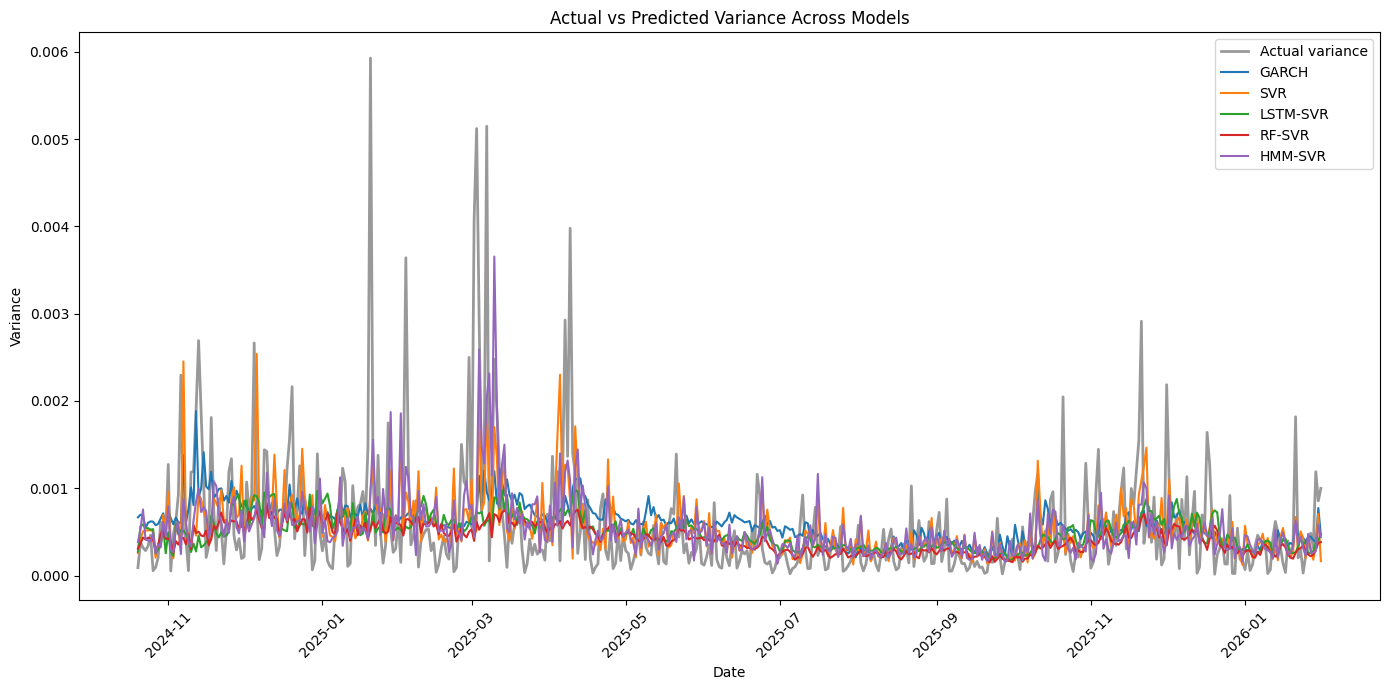

In [54]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1. Read results
# -----------------------------
test_garch = pd.read_csv("benchmark garch/garch.csv")
test_svr = pd.read_csv("SVR/results/svr_test_results.csv")
test_lstmsvr = pd.read_csv("lstm-regimeaware/results/lstm-svr1.csv")
test_rfsvr = pd.read_csv("rf-regimeaware/results/test_rf_results.csv")
test_hmmsvr = pd.read_csv('2_step_hmm_model/results/hmm_svrl_revised_test_results.csv')

# -----------------------------
# 2. Convert to variance scale
# -----------------------------
test_garch["actual_var"] = np.exp(test_garch["actual_var"])
test_garch["pred_garch"] = np.exp(test_garch["var_garch_bench"])

test_svr["pred_svr"] = test_svr["pred_var"]

test_lstmsvr["actual_var"] = np.exp(test_lstmsvr["actual_log_var"])
test_lstmsvr["pred_lstmsvr"] = np.exp(test_lstmsvr["log_var_svr"])

test_rfsvr["actual_var"] = np.exp(test_rfsvr["actual_log_var"])
test_rfsvr["pred_rfsvr"] = np.exp(test_rfsvr["log_var_svr"])

# -----------------------------
# 3. Keep only needed columns
#    adjust "date" if your column name differs
# -----------------------------
garch_df = test_garch[["date", "actual_var", "pred_garch"]].copy()
svr_df = test_svr[["date", "actual_var", "pred_svr"]].copy()
lstm_df = test_lstmsvr[["date", "actual_var", "pred_lstmsvr"]].copy()
rf_df = test_rfsvr[["date", "actual_var", "pred_rfsvr"]].copy()
hmm_df = test_hmmsvr[["date", "actual_var", "forecast_var"]].copy()
hmm_df['date'] = pd.to_datetime(hmm_df['date']) 

# -----------------------------
# 4. Convert dates
# -----------------------------
for df in [garch_df, svr_df, lstm_df, rf_df]:
    df["date"] = pd.to_datetime(df["date"])

# -----------------------------
# 5. Merge everything on date
#    Use one actual_var column from one file
# -----------------------------
plot_df = (
    garch_df[["date", "actual_var", "pred_garch"]]
    .merge(svr_df[["date", "pred_svr"]], on="date", how="inner")
    .merge(lstm_df[["date", "pred_lstmsvr"]], on="date", how="inner")
    .merge(rf_df[["date", "pred_rfsvr"]], on="date", how="inner")
    .merge(hmm_df[["date", "forecast_var"]].rename(columns={"forecast_var": "pred_hmmsvr"}), on="date", how="inner")
    .sort_values("date")
)

# -----------------------------
# 6. Plot
# -----------------------------
plt.figure(figsize=(14, 7))
plt.plot(
    plot_df["date"],
    plot_df["actual_var"],
    label="Actual variance",
    color="black",
    linewidth=2,
    alpha=0.4
)

# models (clear colors)
plt.plot(plot_df["date"], plot_df["pred_garch"], label="GARCH")
plt.plot(plot_df["date"], plot_df["pred_svr"], label="SVR")
plt.plot(plot_df["date"], plot_df["pred_lstmsvr"], label="LSTM-SVR")
plt.plot(plot_df["date"], plot_df["pred_rfsvr"], label="RF-SVR")
plt.plot(plot_df["date"], plot_df["pred_hmmsvr"], label="HMM-SVR")

plt.title("Actual vs Predicted Variance Across Models")
plt.xlabel("Date")
plt.ylabel("Variance")
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()